# PCA + DBSCAN Clustering of Stock Price Movement (Google Colab, upload-and-run)

**How to use.** Runtime -> Run all. The second code cell opens an upload widget;
choose a CSV shaped like this project's `*_clustering_ready.csv` files (one row per
stock, one column per identifier plus one column per trading day of standardised
price). Everything after that cell — preprocessing, PCA, DBSCAN parameter selection,
the DBSCAN fit, a cluster-stability analysis, results and evaluation metrics — runs
automatically with no further input. To process a different CSV, just re-run the
notebook and upload it again.

**Method and citations.** Every modelling choice below is tied to a specific
reference, listed with full detail in the **References** section at the end. In
short:

- DBSCAN itself, its core/border/noise definitions, and its `eps`/`MinPts`
  parameter-selection heuristics are taken directly from **Ester, Kriegel, Sander &
  Xu (1996)** [1], the paper that introduced the algorithm.
- The silhouette coefficient, the silhouette plot, and the rule of picking the
  parameter setting that maximises the average silhouette width are taken directly
  from **Rousseeuw (1987)** [2].
- The `DBSCAN` and evaluation-metric implementations used are `scikit-learn`'s, per
  its **Clustering** [3] and **Clustering performance evaluation** [4] user guides.
- Two extra ingredients the papers above do not cover — **PCA** for dimensionality
  reduction, and **bootstrap/sub-sampling for cluster stability** — are each
  attributed to their own standard, original source ([5] and [9]), separate from the
  materials supplied for this task. They are flagged as such throughout so it is
  always clear which claims come from the supplied papers and which are
  supplementary, well-established statistical method.
- The two metrics scikit-learn implements alongside the silhouette score,
  Calinski-Harabasz [6] and Davies-Bouldin [7], and the Adjusted Rand Index [8] used
  for the stability check and the trend-baseline sanity check, are cited to their own
  original papers, which is also how scikit-learn's own documentation [4] attributes
  them.


In [1]:
import io
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score,
)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded.")

Libraries loaded.


## 1. Upload a CSV

Expected shape: one identifier column (e.g. `Ticker`) followed by one numeric column
per trading day, holding each stock's standardised (z-scored) closing price — exactly
the format of this project's `ftse_clustering_ready.csv`,
`ftse250_clustering_ready.csv` and `ftse2501_clustering_ready.csv`. Re-run this cell
(or Runtime -> Run all) to load a different file; every later cell then regenerates
automatically from whatever was just uploaded.

In [2]:
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Select a CSV file to upload...")
    uploaded = files.upload()
    FILENAME = list(uploaded.keys())[0]
    raw_bytes = uploaded[FILENAME]
else:
    # Fallback so the notebook can also be run and tested outside Colab.
    FILENAME = "ftse250_clustering_ready.csv"
    raw_bytes = open(FILENAME, "rb").read()

print("Using file:", FILENAME)

Using file: ftse250_clustering_ready.csv


## 2. Parse and clean

The identifier column is auto-detected as the first non-numeric column (falling back
to the first column if every column parses as numeric); every other column is treated
as one point in an ordered numeric sequence (a trading day). Rows missing more than
`MAX_MISSING_FRAC` of their history are dropped; any remaining gaps are forward- then
backward-filled. This is routine data hygiene, not a modelling choice, so it carries
no citation of its own.

In [3]:
MAX_MISSING_FRAC = 0.10

df = pd.read_csv(io.BytesIO(raw_bytes))

id_col = None
for c in df.columns:
    if not pd.api.types.is_numeric_dtype(df[c]):
        id_col = c
        break
if id_col is None:
    id_col = df.columns[0]

feature_cols = [c for c in df.columns if c != id_col]
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")

frac_missing = df[feature_cols].isna().sum(axis=1) / len(feature_cols)
n_dropped = int((frac_missing > MAX_MISSING_FRAC).sum())
df = df.loc[frac_missing <= MAX_MISSING_FRAC].reset_index(drop=True)
df[feature_cols] = df[feature_cols].ffill(axis=1).bfill(axis=1)

entity_ids = df[id_col].values
X_raw = df[feature_cols].values.astype(float)

print(f"Identifier column: '{id_col}'")
print(f"{X_raw.shape[0]} entities kept, {n_dropped} dropped for >{MAX_MISSING_FRAC:.0%} missing history")
print(f"Feature matrix: {X_raw.shape[0]} entities x {X_raw.shape[1]} time points")

Identifier column: 'Ticker'
241 entities kept, 0 dropped for >10% missing history
Feature matrix: 241 entities x 1153 time points


## 3. Standardised trajectory features, then PCA [5]

Each row is already a per-entity time series (e.g. a standardised daily closing
price), whose *shape over time* — its rises, falls and turning points — is exactly
the movement pattern this project studies. That series is first standardised
column-by-column (zero mean, unit variance per time-step, across entities) with
`StandardScaler`, the routine preprocessing PCA needs since it operates on variance
and is scale-sensitive; this also makes the pipeline work uniformly on any uploaded
CSV, whether or not it happens to arrive pre-standardised.

**PCA** (Principal Component Analysis) [5] is then applied to reduce the
high-dimensional, highly auto-correlated time-step matrix down to a small number of
near-independent components, retaining enough components to explain a fixed share of
the total variance. This keeps the subsequent nearest-neighbour distances DBSCAN
relies on (Section 4 below) meaningful, rather than diluted across thousands of
correlated time columns.

(Day-to-day *differences* of the series were also tried as the PCA input, since they
more narrowly isolate movement from level. Empirically they compress far worse under
PCA — the cumulative-variance curve is nearly flat, needing well over a hundred
components for 90% of the variance, because successive daily changes are close to
noise. That many dimensions makes Euclidean nearest-neighbour distances practically
meaningless — every point ends up roughly equidistant from every other — which
breaks the density assumption DBSCAN [1] depends on. The trajectory itself, used
below, compresses to under a dozen components and keeps that density assumption
meaningful.)

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Standardised feature matrix: {X_scaled.shape}")

Standardised feature matrix: (241, 1153)


PCA [5]: 1153 time-steps -> 10 components (90% of variance retained)
PC1 alone explains 41.1% of variance


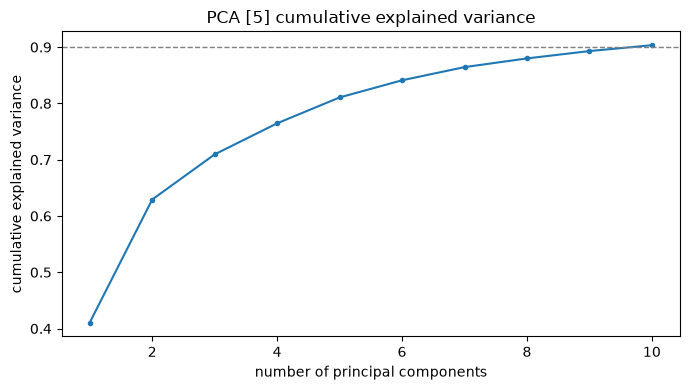

In [5]:
VARIANCE_TARGET = 0.90

pca = PCA(n_components=VARIANCE_TARGET, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA [5]: {X_scaled.shape[1]} time-steps -> {X_pca.shape[1]} components "
      f"({VARIANCE_TARGET:.0%} of variance retained)")
print(f"PC1 alone explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance")

fig, ax = plt.subplots(figsize=(7, 4))
cum_var = np.cumsum(pca.explained_variance_ratio_)
ax.plot(np.arange(1, len(cum_var) + 1), cum_var, marker="o", ms=3)
ax.axhline(VARIANCE_TARGET, color="gray", ls="--", lw=1)
ax.set_xlabel("number of principal components")
ax.set_ylabel("cumulative explained variance")
ax.set_title("PCA [5] cumulative explained variance")
plt.tight_layout()
plt.show()

## 4. DBSCAN [1]: choosing `eps` and `MinPts`

**Definitions, directly from the paper [1].** For a point `p`, its `Eps`-neighbourhood
is `N_Eps(p) = {q : dist(p, q) <= Eps}` (Definition 1). `p` is a **core point** if
`|N_Eps(p)| >= MinPts` (the core-point condition inside Definition 2). A point
density-reachable from some core point is placed in that point's cluster — a **border
point** if it is not itself a core point. A **cluster** is a maximal set of points
that are density-connected (Definitions 3-5); points reachable from no core point at
all are **noise** (Definition 6).

**Choosing `eps` (Section 4.2).** The paper gives two ways to set `eps` once `MinPts`
is fixed:

1. Plot the **sorted k-dist graph** — each point's distance to its `k`-th nearest
   neighbour (`k = MinPts`), sorted in descending order — and read off `eps` as the
   value at the graph's "first valley", which the paper notes is easy for a person to
   see but "very difficult to detect ... automatically".
2. *"If the user can estimate the percentage of noise, this percentage is entered
   and the system derives a proposal for the threshold point from it"* — i.e. `eps`
   is simply the `k-dist` value at that percentile of the sorted graph.

Because this notebook must run unattended after every upload, rule 2 is used exactly
as stated, but automated by sweeping a small set of plausible noise percentages
instead of asking a person for one number. Rule 1's graph is still plotted below, as
in the paper's Figure 4, purely so a human reviewer can sanity-check the choice
visually.

The paper additionally fixes `MinPts = 4` as a default, but only *"for 2-dimensional
data"* — our PCA space has more than 2 dimensions, so instead of reusing that number
out of context, `MinPts` is swept over a small candidate list alongside `eps`, and
**Section 4.1 below** picks the winning pair.

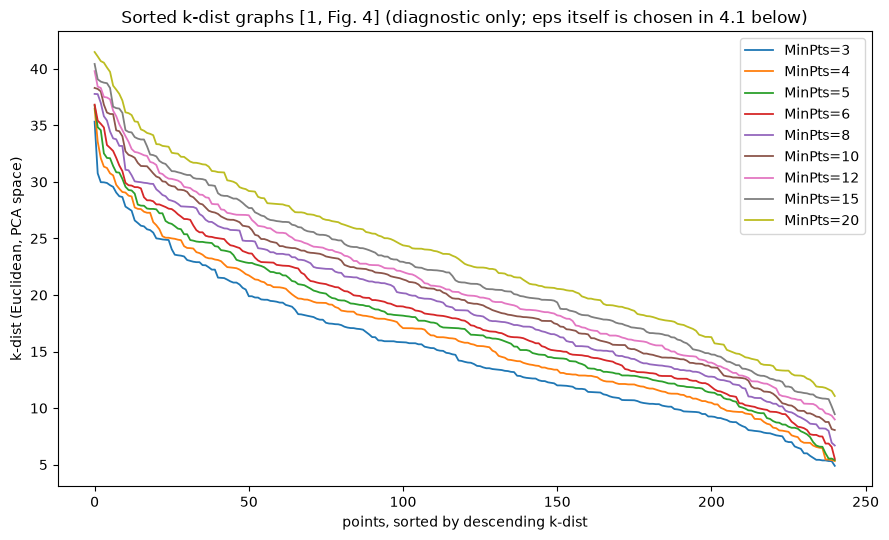

In [6]:
MINPTS_CANDIDATES = [3, 4, 5, 6, 8, 10, 12, 15, 20]
NOISE_PCT_CANDIDATES = [1, 2, 5, 10, 15, 20, 25, 30, 35, 40, 50]

nbrs_cache = {}
for k in MINPTS_CANDIDATES:
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean").fit(X_pca)
    dist, _ = nn.kneighbors(X_pca)
    nbrs_cache[k] = np.sort(dist[:, -1])[::-1]      # k-dist, sorted descending (paper Fig. 4)

fig, ax = plt.subplots(figsize=(9, 5.5))
for k in MINPTS_CANDIDATES:
    ax.plot(np.arange(len(nbrs_cache[k])), nbrs_cache[k], lw=1.3, label=f"MinPts={k}")
ax.set_xlabel("points, sorted by descending k-dist")
ax.set_ylabel("k-dist (Euclidean, PCA space)")
ax.set_title("Sorted k-dist graphs [1, Fig. 4] (diagnostic only; eps itself is chosen in 4.1 below)")
ax.legend()
plt.tight_layout()
plt.show()

### 4.1 Selecting `(eps, MinPts)` by maximum average silhouette width [2]

For every `(MinPts, noise%)` combination, `eps` is set to the `k-dist` value at that
noise percentile (the paper's own rule 2 above), DBSCAN [1] is fit, and the resulting
partition's **average silhouette width `S`** is computed exactly as Rousseeuw [2]
defines it:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}, \qquad S = \text{mean}_i\, s(i)$$

where `a(i)` is `i`'s average distance to the rest of its own cluster and `b(i)` its
average distance to the nearest other cluster. Rousseeuw [2] proposes choosing
whichever candidate partition **maximises `S`** as the most appropriate one (he
illustrates this by sweeping the number of clusters `k` for k-medoids; here the same
maximisation is applied over DBSCAN's own free parameters instead, since DBSCAN has
no `k` to sweep directly). `sklearn.metrics.silhouette_score` [3, 4] implements this
same `a(i)`, `b(i)`, `s(i)` construction. Noise points are excluded, since they belong
to no cluster for `a(i)`/`b(i)` to be computed against — standard practice, and
required by `silhouette_score` itself (it needs at least 2 labels present).

In [7]:
NOISE_CEILING = 0.90          # candidate rejected if >90% of points end up as noise
GIANT_CLUSTER_CEILING = 0.90  # or if one cluster holds >90% of the non-noise points
MIN_CLUSTERS = 2

rows = []
for k in MINPTS_CANDIDATES:
    kd = nbrs_cache[k]
    for pct in NOISE_PCT_CANDIDATES:
        idx = int(round(pct / 100.0 * (len(kd) - 1)))
        eps = kd[idx]
        labels = DBSCAN(eps=eps, min_samples=k, metric="euclidean").fit_predict(X_pca)

        non_noise = labels != -1
        n_clusters = len(set(labels[non_noise]))
        noise_frac = 1.0 - non_noise.mean()
        largest_frac = (pd.Series(labels[non_noise]).value_counts(normalize=True).max()
                         if non_noise.any() else np.nan)

        sil = np.nan
        if n_clusters >= MIN_CLUSTERS and non_noise.sum() > n_clusters:
            sil = silhouette_score(X_pca[non_noise], labels[non_noise], metric="euclidean")

        rows.append(dict(MinPts=k, noise_pct_rule=pct, eps=eps, n_clusters=n_clusters,
                          noise_frac=noise_frac, largest_frac=largest_frac, silhouette=sil))

grid = pd.DataFrame(rows)
print(f"Evaluated {len(grid)} (MinPts, eps) combinations")
grid.sort_values("silhouette", ascending=False).head(10)

Evaluated 99 (MinPts, eps) combinations


,MinPts,noise_pct_rule,eps,n_clusters,noise_frac,largest_frac,silhouette
98,20,50,22.756546,2,0.224066,0.705882,0.462166
21,4,50,15.779657,3,0.439834,0.666667,0.336018
32,5,50,16.999139,3,0.398340,0.648276,0.334606
10,3,50,14.089625,5,0.448133,0.646617,0.302259
17,4,25,20.677996,2,0.182573,0.979695,0.191614
9,3,40,15.908248,6,0.336100,0.587500,0.153128
5,3,20,20.631990,2,0.153527,0.985294,0.008908
7,3,30,17.904605,3,0.236515,0.967391,0.000615
6,3,25,19.331146,3,0.186722,0.969388,-0.008684
8,3,35,17.069938,3,0.302905,0.964286,-0.028367


In [8]:
valid = grid[
    (grid["n_clusters"] >= MIN_CLUSTERS)
    & (grid["noise_frac"] <= NOISE_CEILING)
    & (grid["largest_frac"] <= GIANT_CLUSTER_CEILING)
    & grid["silhouette"].notna()
]
print(f"Non-degenerate combinations: {len(valid)} / {len(grid)}")

pool = valid if len(valid) else grid
if not len(valid):
    print("WARNING: every combination was degenerate by the ceilings above; "
          "picking the best of the full grid instead.")

best = pool.sort_values("silhouette", ascending=False).iloc[0]
MINPTS, EPS, BEST_NOISE_PCT = int(best["MinPts"]), float(best["eps"]), int(best["noise_pct_rule"])
print(f"\nSelected by maximum average silhouette width S [2]:")
print(f"  MinPts = {MINPTS}")
print(f"  eps    = {EPS:.4f}  (from the {BEST_NOISE_PCT}% noise rule [1, Sec 4.2])")
print(f"  clusters = {int(best['n_clusters'])}, noise = {best['noise_frac']:.1%}, "
      f"S = {best['silhouette']:.3f}")

Non-degenerate combinations: 5 / 99

Selected by maximum average silhouette width S [2]:
  MinPts = 20
  eps    = 22.7565  (from the 50% noise rule [1, Sec 4.2])
  clusters = 2, noise = 22.4%, S = 0.462


## 4.2 Final DBSCAN [1] fit: core, border and noise points

Fitting DBSCAN with the selected `(eps, MinPts)` assigns every point exactly one of
the three roles defined in the paper (Section 3): a **core point** if its
neighbourhood held at least `MinPts` points (`core_sample_indices_` in scikit-learn
[3]); a **border point** if it is density-reachable from a core point but is not one
itself; or **noise** (`label == -1`) if it is reachable from no core point at
all (Definition 6).

In [9]:
final = DBSCAN(eps=EPS, min_samples=MINPTS, metric="euclidean")
labels = final.fit_predict(X_pca)
n = len(labels)

is_core = np.zeros(n, dtype=bool)
is_core[final.core_sample_indices_] = True
is_border = (~is_core) & (labels != -1)
is_noise = labels == -1

cluster_ids = sorted(set(labels[labels != -1]))
n_clusters = len(cluster_ids)
sizes = pd.Series(labels[labels != -1]).value_counts().sort_index()

print(f"eps={EPS:.4f}, MinPts={MINPTS}")
print(f"{n_clusters} clusters found")
print(f"  core points:   {is_core.sum():>4d} ({is_core.mean():.1%})")
print(f"  border points: {is_border.sum():>4d} ({is_border.mean():.1%})")
print(f"  noise points:  {is_noise.sum():>4d} ({is_noise.mean():.1%})")
print("\nCluster sizes:")
print(sizes.rename("n_entities"))

eps=22.7565, MinPts=20
2 clusters found
  core points:    121 (50.2%)
  border points:   66 (27.4%)
  noise points:    54 (22.4%)

Cluster sizes:
0    132
1     55
Name: n_entities, dtype: int64


## 5. Cluster-stability analysis

Neither [1] nor [2] addresses stability, so this section is built entirely from two
standard, separately-cited techniques:

- **Sub-sampling** is the practical, no-duplicates variant of **Efron's (1979)
  bootstrap** [9]: draw a random `frac` of the entities *without* replacement (a
  literal bootstrap, sampling *with* replacement, would create duplicate points,
  artificially inflating the neighbour counts a density-based method like DBSCAN
  relies on).
- Agreement between the resulting partition and the original one, on the entities
  they share, is measured with the **Adjusted Rand Index (ARI)** [8], exactly as
  implemented by `sklearn.metrics.adjusted_rand_score` [4].

On each of `B` replicates, the **entire** pipeline — `StandardScaler` -> PCA [5] ->
DBSCAN [1] — is refit from scratch on the subsample, so what is being tested is the
stability of the whole procedure, not just of DBSCAN in isolation.

**`eps` cannot simply be reused across replicates.** PCA is refit from scratch on
each subsample, so its components — and the distance scale they induce — are not the
same PCA space the full-data `eps` was calibrated to; a fixed numeric `eps` value
copied over from Section 4.1 would be measuring density against the wrong ruler on
every replicate. What *is* held fixed, instead, is the **selection rule** for `eps`:
the same `MinPts` and the same noise-percentile [1, Sec 4.2] chosen in Section 4.1
(`BEST_NOISE_PCT`) are re-applied to each subsample's own sorted k-dist graph, so
`eps` is re-derived freshly, on its own PCA space, every time — the density
*criterion* stays constant across replicates, the *number* adapts to each subsample's
geometry, exactly as it should.

The subsample's labels are then compared via ARI [8] to the original model's labels,
restricted to that same subsample of entities. `ARI = 1` means perfect agreement (up
to relabelling), `ARI ~ 0` matches what two independent random partitions would give,
and it can dip slightly negative.

Cluster-stability analysis (B=30 sub-samples [9] of 80% of entities, eps re-derived per subsample via the same MinPts=20 / 50% noise rule [1], agreement via ARI [8]):
  mean ARI = 0.664
  std  ARI = 0.231
  min / max ARI = 0.348 / 0.956


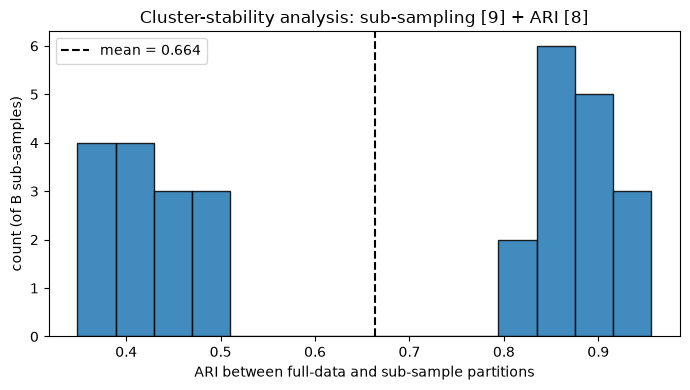

=> The clustering shows moderate stability; some cluster structure is sample-dependent.


In [10]:
def stability_analysis(X_features, minpts, noise_pct, labels_full, B=30, frac=0.8, seed=RANDOM_STATE):
    rng_local = np.random.default_rng(seed)
    n_local = X_features.shape[0]
    m = int(round(frac * n_local))
    scores = []
    for _ in range(B):
        idx = rng_local.choice(n_local, size=m, replace=False)
        sub_scaled = StandardScaler().fit_transform(X_features[idx])
        sub_pca = PCA(n_components=VARIANCE_TARGET, random_state=seed).fit_transform(sub_scaled)

        # Re-derive eps on THIS subsample's own PCA space, using the same
        # (MinPts, noise-percentile) rule [1, Sec 4.2] selected in Section 4.1 --
        # reusing the full-data eps number here would be invalid, since PCA was
        # just refit and its distance scale is not guaranteed to match.
        nn_sub = NearestNeighbors(n_neighbors=minpts, metric="euclidean").fit(sub_pca)
        dist_sub, _ = nn_sub.kneighbors(sub_pca)
        kd_sub = np.sort(dist_sub[:, -1])[::-1]
        idx_pct = int(round(noise_pct / 100.0 * (len(kd_sub) - 1)))
        eps_sub = kd_sub[idx_pct]

        sub_labels = DBSCAN(eps=eps_sub, min_samples=minpts, metric="euclidean").fit_predict(sub_pca)
        scores.append(adjusted_rand_score(labels_full[idx], sub_labels))
    return np.array(scores)


stability_scores = stability_analysis(X_raw, MINPTS, BEST_NOISE_PCT, labels, B=30, frac=0.8)

print(f"Cluster-stability analysis (B=30 sub-samples [9] of 80% of entities, "
      f"eps re-derived per subsample via the same MinPts={MINPTS} / "
      f"{BEST_NOISE_PCT}% noise rule [1], agreement via ARI [8]):")
print(f"  mean ARI = {stability_scores.mean():.3f}")
print(f"  std  ARI = {stability_scores.std():.3f}")
print(f"  min / max ARI = {stability_scores.min():.3f} / {stability_scores.max():.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(stability_scores, bins=15, color="C0", edgecolor="k", alpha=0.85)
ax.axvline(stability_scores.mean(), color="k", ls="--", lw=1.5,
           label=f"mean = {stability_scores.mean():.3f}")
ax.set_xlabel("ARI between full-data and sub-sample partitions")
ax.set_ylabel("count (of B sub-samples)")
ax.set_title("Cluster-stability analysis: sub-sampling [9] + ARI [8]")
ax.legend()
plt.tight_layout()
plt.show()

if stability_scores.mean() > 0.7:
    print("=> The clustering is highly stable under 20% data removal and a full pipeline refit.")
elif stability_scores.mean() > 0.4:
    print("=> The clustering shows moderate stability; some cluster structure is sample-dependent.")
else:
    print("=> The clustering is not very stable; treat the specific clusters found with caution.")

## 6. Results

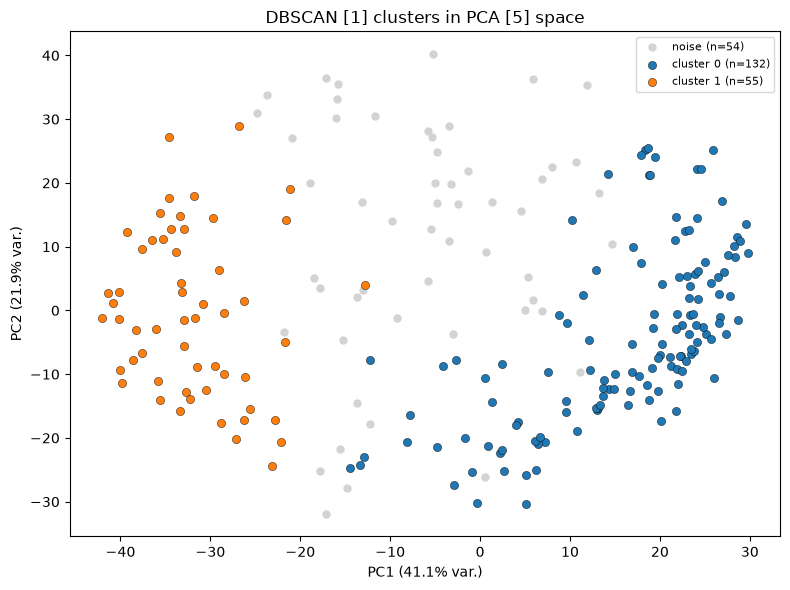

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[is_noise, 0], X_pca[is_noise, 1], c="lightgray", s=25,
           label=f"noise (n={is_noise.sum()})", zorder=1)
for c in cluster_ids:
    m = labels == c
    ax.scatter(X_pca[m, 0], X_pca[m, 1], c=f"C{c % 10}", s=35,
               label=f"cluster {c} (n={m.sum()})", zorder=2, edgecolor="k", linewidth=0.3)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
ax.set_title("DBSCAN [1] clusters in PCA [5] space")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

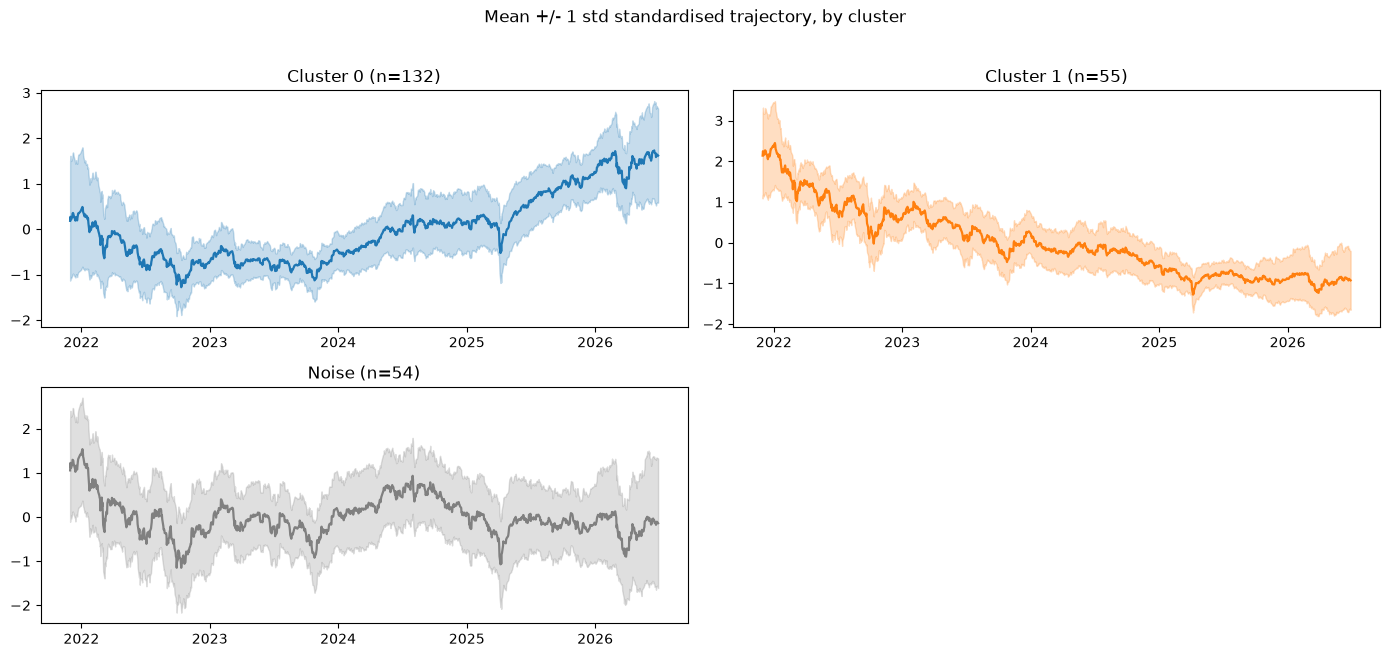

In [12]:
try:
    t_labels = pd.to_datetime(feature_cols)
    t_axis = t_labels
except (ValueError, TypeError):
    t_axis = np.arange(X_raw.shape[1])

n_panels = n_clusters + 1
n_cols = 2
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.2 * n_rows), squeeze=False)

panel = 0
for c in cluster_ids:
    ax = axes[panel // n_cols][panel % n_cols]
    mem = X_raw[labels == c]
    mu, sd = mem.mean(axis=0), mem.std(axis=0)
    ax.plot(t_axis, mu, color=f"C{c % 10}", lw=1.6)
    ax.fill_between(t_axis, mu - sd, mu + sd, color=f"C{c % 10}", alpha=0.25)
    ax.set_title(f"Cluster {c} (n={mem.shape[0]})")
    panel += 1

ax = axes[panel // n_cols][panel % n_cols]
mem = X_raw[is_noise]
mu, sd = mem.mean(axis=0), mem.std(axis=0)
ax.plot(t_axis, mu, color="gray", lw=1.6)
ax.fill_between(t_axis, mu - sd, mu + sd, color="gray", alpha=0.25)
ax.set_title(f"Noise (n={mem.shape[0]})")
panel += 1

for p in range(panel, n_rows * n_cols):
    axes[p // n_cols][p % n_cols].axis("off")

fig.suptitle("Mean +/- 1 std standardised trajectory, by cluster", y=1.02)
plt.tight_layout()
plt.show()

In [13]:
for c in cluster_ids:
    mem = sorted(str(x) for x in entity_ids[labels == c])
    print(f"Cluster {c} (n={len(mem)}):")
    print(textwrap.fill(", ".join(mem), width=95))
    print()

noise_members = sorted(str(x) for x in entity_ids[is_noise])
print(f"Noise (n={len(noise_members)}):")
print(textwrap.fill(", ".join(noise_members), width=95))

Cluster 0 (n=132):
3IN.L, AAS.L, AEP.L, AGT.L, AIE.L, AJB.L, ALFA.L, AO.L, ASL.L, ATR.L, ATT.L, ATYM.L, AVON.L,
BAG.L, BBY.L, BCG.L, BGFD.L, BMY.L, BNKR.L, BPCR.L, BPT.L, BRGE.L, BRWM.L, BUT.L, CGT.L, CHG.L,
CKN.L, CLDN.L, COA.L, CORD.L, COST.L, CSN.L, CTY.L, CURY.L, CWK.L, DRX.L, EDIN.L, ELM.L,
ESCT.L, EWI.L, FAN.L, FCH.L, FCSS.L, FEML.L, FEV.L, FGP.L, FSV.L, GDWN.L, GFRD.L, GNC.L,
GROW.L, GSCT.L, HANA.L, HGT.L, HILS.L, HMSO.L, HOC.L, HRI.L, HSL.L, HTG.L, HTWS.L, HVPE.L,
HWG.L, IAD.L, ICGT.L, IPF.L, ITV.L, IWG.L, JAM.L, JCH.L, JEDT.L, JEGI.L, JEMI.L, JFJ.L, JGGI.L,
JMGI.L, JSG.L, JTC.L, JUP.L, KIE.L, KLR.L, LWDB.L, MAB.L, MEGP.L, MGNS.L, MNKS.L, MNTN.L,
MRC.L, MRCH.L, MTO.L, MUT.L, MYI.L, N91.L, OCI.L, OSB.L, OXB.L, PAF.L, PAG.L, PCGH.L, PFD.L,
PHI.L, PIN.L, PINT.L, PLUS.L, PNL.L, POLN.L, PPET.L, PPH.L, QLT.L, QQ.L, RCP.L, RNK.L, ROR.L,
RTW.L, SAGA.L, SDP.L, SNR.L, SOI.L, SRP.L, TBCG.L, TCAP.L, TEM.L, TFIF.L, THRL.L, TMPL.L,
TRST.L, TRY.L, UEM.L, USA.L, VEIL.L, WIX.L, XPS.L

Cluster 1

## 7. Evaluation metrics

### 7.1 Silhouette [2] — before, then after, removing noise

Silhouette is computed twice, deliberately in this order:

1. **Before removing DBSCAN's noise** — over *all* entities, treating noise
   (`label == -1`) as its own group. `silhouette_score` [2, 4] does not know or care
   that `-1` means "noise"; it only needs >= 2 distinct labels, so this is a direct,
   unmodified application of the same cited formula, over 100% of the data.
2. **After removing noise** — restricted to the entities DBSCAN actually placed in a
   cluster, which is narrower by construction: Rousseeuw's [2] original `a(i)`/`b(i)`
   assume cluster membership, so a noise point has no natural `a(i)` under that
   definition. This is the figure the Rousseeuw-style plot below is built from
   (Figs. 2-5, 7 of [2]: objects ranked in decreasing `s(i)` within each cluster),
   and it is always reported together with its coverage — the fraction of entities
   it was actually computed over — so it is never mistaken for a whole-sample number.


Silhouette BEFORE removing noise (noise as its own group) [2, 4] = 0.275  (coverage: 100% of entities, 241/241)
Silhouette AFTER removing noise [2, 4]                            = 0.462  (coverage: 187/241 = 77.6% of entities)


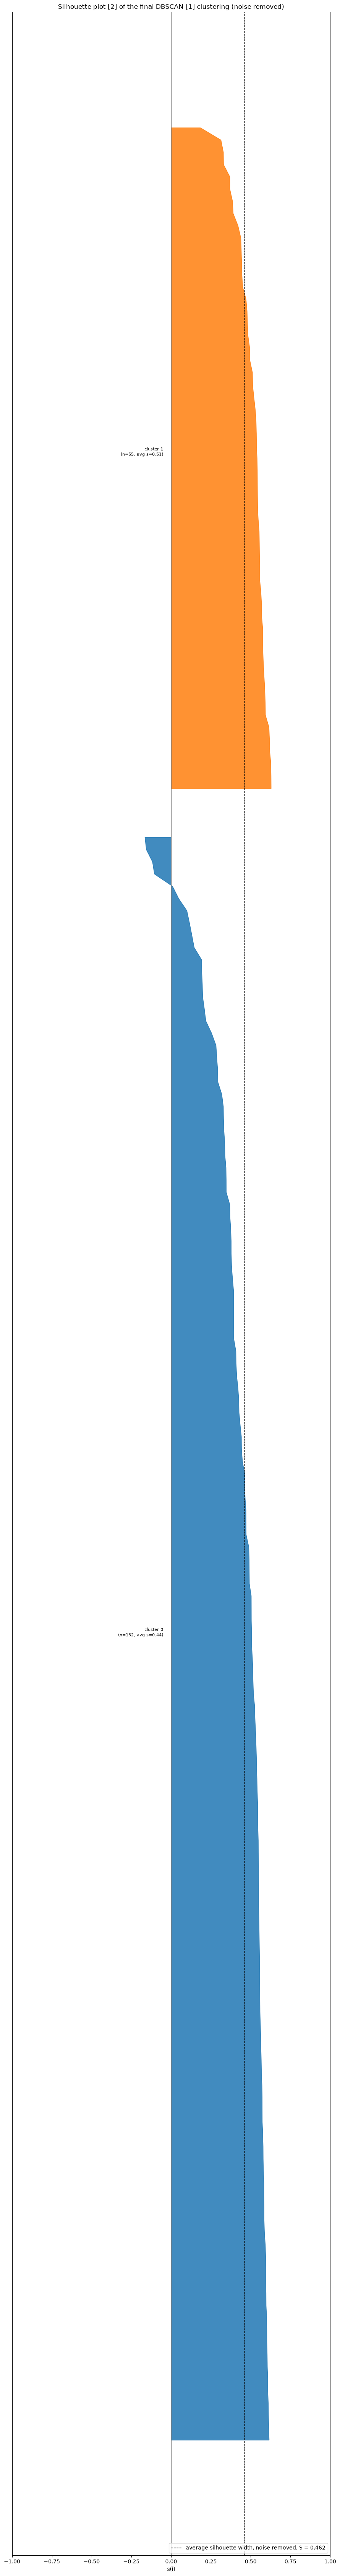

In [14]:
non_noise = labels != -1
coverage = non_noise.mean()

# 1. Silhouette BEFORE removing noise -- all entities, noise as its own group.
n_unique_all = len(set(labels))
if 1 < n_unique_all < n:
    S_all = silhouette_score(X_pca, labels, metric="euclidean")
    print(f"Silhouette BEFORE removing noise (noise as its own group) [2, 4] = {S_all:.3f}  "
          f"(coverage: 100% of entities, {n}/{n})")
else:
    S_all = np.nan
    print("Silhouette before removing noise: undefined (fewer than 2 distinct groups).")

# 2. Silhouette AFTER removing noise -- restricted to non-noise entities.
sv = silhouette_samples(X_pca[non_noise], labels[non_noise], metric="euclidean")
S_overall = sv.mean()
print(f"Silhouette AFTER removing noise [2, 4]                            = {S_overall:.3f}  "
      f"(coverage: {non_noise.sum()}/{n} = {coverage:.1%} of entities)")

fig, ax = plt.subplots(figsize=(9, 0.35 * non_noise.sum() + 2))
y0 = 0
for c in cluster_ids:
    v = np.sort(sv[labels[non_noise] == c])[::-1]     # decreasing s(i), as in [2]
    y = np.arange(y0, y0 + len(v))
    ax.fill_betweenx(y, 0, v, color=f"C{c % 10}", alpha=0.85)
    ax.text(-0.05, y0 + len(v) / 2, f"cluster {c}\n(n={len(v)}, avg s={v.mean():.2f})",
            ha="right", va="center", fontsize=8)
    y0 += len(v) + 3

ax.axvline(S_overall, color="k", ls="--", lw=1,
           label=f"average silhouette width, noise removed, S = {S_overall:.3f}")
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlim(-1, 1)
ax.set_yticks([])
ax.set_xlabel("s(i)")
ax.set_title("Silhouette plot [2] of the final DBSCAN [1] clustering (noise removed)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 7.2 Calinski-Harabasz [6] and Davies-Bouldin [7] indices

Both are implemented by scikit-learn [4] alongside the silhouette score, and both
need feature vectors in Euclidean space rather than a precomputed distance matrix —
satisfied here directly, since clustering itself was already done on the Euclidean
PCA [5] coordinates `X_pca`. One documented caveat from scikit-learn's guide [4]
applies directly to this notebook: all of these indices are *"generally higher for
convex clusters than other concepts of clusters, such as density-based clusters like
those obtained through DBSCAN"* — so read the numbers below as a relative comparison
across this notebook's own candidate parameter settings, not as an absolute mark of
quality.

In [15]:
ch = calinski_harabasz_score(X_pca[non_noise], labels[non_noise])
db = davies_bouldin_score(X_pca[non_noise], labels[non_noise])

print(f"Silhouette, before removing noise [2, 4]  (coverage 100%):        {S_all:.3f}")
print(f"Silhouette, after removing noise [2, 4]   (coverage {coverage:.1%}):      {S_overall:.3f}")
print(f"Calinski-Harabasz index [6, 4]             (coverage {coverage:.1%}):      {ch:.1f}")
print(f"Davies-Bouldin index [7, 4]                (coverage {coverage:.1%}):      {db:.3f}")


Silhouette, before removing noise [2, 4]  (coverage 100%):        0.275
Silhouette, after removing noise [2, 4]   (coverage 77.6%):      0.462
Calinski-Harabasz index [6, 4]             (coverage 77.6%):      183.8
Davies-Bouldin index [7, 4]                (coverage 77.6%):      0.845


### 7.3 Adjusted Rand Index [8] against a naive trend baseline

A final external sanity check, in the spirit of `adjusted_rand_score`'s [4] intended
use of comparing two independent partitions of the same objects: does DBSCAN [1] just
rediscover the sign of each entity's overall trend, or capture something a trivial
rule would miss?

In [16]:
t_full = np.arange(X_raw.shape[1])
trend = np.array([np.polyfit(t_full, row, 1)[0] for row in X_raw])
trend_sign = (trend > 0).astype(int)

ari_trend = adjusted_rand_score(labels, trend_sign)   # noise (-1) counted as its own group
print(f"ARI(DBSCAN clusters incl. noise, sign-of-trend) [8] = {ari_trend:.3f}")
if ari_trend > 0.7:
    print("=> The clustering is largely a restatement of trend direction.")
elif ari_trend > 0.3:
    print("=> Trend explains part of the clustering, but not all of it.")
else:
    print("=> The clustering is capturing movement structure beyond simple trend direction.")

ARI(DBSCAN clusters incl. noise, sign-of-trend) [8] = 0.474
=> Trend explains part of the clustering, but not all of it.


## References

**Supplied for this task:**

1. M. Ester, H.-P. Kriegel, J. Sander, X. Xu (1996). *A Density-Based Algorithm for
   Discovering Clusters in Large Spatial Databases with Noise.* KDD-96.
2. P. J. Rousseeuw (1987). *Silhouettes: A Graphical Aid to the Interpretation and
   Validation of Cluster Analysis.* Journal of Computational and Applied Mathematics,
   20, 53-65.
3. scikit-learn developers. *Clustering* (`sklearn.cluster.DBSCAN`), scikit-learn
   User Guide. https://scikit-learn.org/stable/modules/clustering.html#dbscan
4. scikit-learn developers. *Clustering performance evaluation*, scikit-learn User
   Guide. https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation

**Standard supporting references** (for methods requested that [1]-[4] do not cover;
not among the materials supplied):

5. K. Pearson (1901). *On lines and planes of closest fit to systems of points in
   space.* Philosophical Magazine, 2(11), 559-572. — origin of PCA.
6. T. Calinski & J. Harabasz (1974). *A dendrite method for cluster analysis.*
   Communications in Statistics, 3(1), 1-27. — origin of the Calinski-Harabasz index,
   as implemented and cited by [4].
7. D. L. Davies & D. W. Bouldin (1979). *A Cluster Separation Measure.* IEEE
   Transactions on Pattern Analysis and Machine Intelligence, PAMI-1(2), 224-227. —
   origin of the Davies-Bouldin index, as implemented and cited by [4].
8. L. Hubert & P. Arabie (1985). *Comparing partitions.* Journal of Classification,
   2(1), 193-218. — origin of the (Adjusted) Rand Index, as implemented and cited by
   [4].
9. B. Efron (1979). *Bootstrap methods: another look at the jackknife.* The Annals of
   Statistics, 7(1), 1-26. — origin of resampling-based stability assessment,
   adapted here to sub-sampling without replacement for the reason given in Section 5.
